In [2]:
!pip install pandas
!pip install seaborn
!pip install matplotlib
!pip install numpy

In [3]:
# Cell 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Load, Clean, and Inspect Data**

In [4]:
import pandas as xyz_data
import os

xyz_file_path = '/content/drive/MyDrive/Desktop/PlayerStats.csv'

# List of encodings to try
xyz_encodings = ['utf-8', 'latin-1', 'cp1252', 'ISO-8859-2']
xyz_dataframe = None

for xyz_enc in xyz_encodings:
    try:
        xyz_dataframe = xyz_data.read_csv(xyz_file_path, encoding=xyz_enc)
        print(f"Successfully loaded file with encoding: {xyz_enc}")
        break
    except UnicodeDecodeError:
        print(f"Failed to load with encoding: {xyz_enc}")
        continue
    except FileNotFoundError:
        print(f"Error: File not found at {xyz_file_path}. Please check your Drive mount and path.")
        break
    except Exception as xyz_e:
        print(f"An unexpected error occurred: {xyz_e}")
        break

if xyz_dataframe is not None:
    xyz_dataframe['value'] = (
        xyz_dataframe['value']
        .str.replace('$', '', regex=False)
        .str.replace('.', '', regex=False)
        .astype(float)
    )
    xyz_dataframe.columns = xyz_dataframe.columns.str.replace(' ', '_')

    print(xyz_dataframe.head())
    print(xyz_dataframe.info())
else:
    print("Could not load the dataframe with any tested encoding.")

Failed to load with encoding: utf-8
Successfully loaded file with encoding: latin-1
                     player   country  height  weight  age               club  \
0  Cristian Castro Devenish  Colombia     192      84   22        Real Madrid   
1          Silaldo Taffarel    Brazil     181      80   31       FC Barcelona   
2              Thomas Dähne   Germany     193      84   29    Manchester City   
3         Michael Sollbauer   Austria     187      86   33          Liverpool   
4             Diego Segovia   Uruguay     191      80   23  FC Bayern München   

   ball_control  dribbling  marking  slide_tackle  ...  curve  fk_acc  \
0            55         43      NaN            68  ...     32      34   
1            69         70      NaN            56  ...     65      62   
2            25         12      NaN            13  ...     20      15   
3            46         48      NaN            66  ...     25      13   
4            14          8      NaN            14  ...      9   

### **Descriptive Statistics for Player Attributes**

In [5]:
import numpy as xyz_numpy

# Select numerical columns of interest
xyz_num_cols = ['height', 'weight', 'age', 'value', 'reactions', 'composure']

# Ensure columns are numeric and drop rows with NaN for a clean summary
for xyz_col in xyz_num_cols:
    xyz_dataframe[xyz_col] = xyz_data.to_numeric(xyz_dataframe[xyz_col], errors='coerce')

xyz_summary_df = xyz_dataframe[xyz_num_cols].dropna()

print('--- Descriptive Statistics for Player Attributes ---')
print(xyz_summary_df.describe().T)

--- Descriptive Statistics for Player Attributes ---
            count          mean           std    min      25%      50%  \
height     5682.0  1.816705e+02  6.829238e+00  156.0    177.0    182.0   
weight     5682.0  7.528229e+01  6.998971e+00   54.0     70.0     75.0   
age        5682.0  2.631626e+01  4.729967e+00   17.0     23.0     26.0   
value      5682.0  2.271115e+06  7.616233e+06  400.0  35000.0  77500.0   
reactions  5682.0  6.195935e+01  8.893309e+00   32.0     56.0     62.0   
composure  5682.0  5.862091e+01  1.202410e+01   13.0     52.0     60.0   

                 75%          max  
height         186.0        204.0  
weight          80.0        102.0  
age             30.0         41.0  
value      1600000.0  153500000.0  
reactions       68.0         93.0  
composure       67.0         96.0  


### **Number of players in each Club (Bar Chart)**

/tmp/ipython-input-3524259116.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  xyz_sns.barplot(


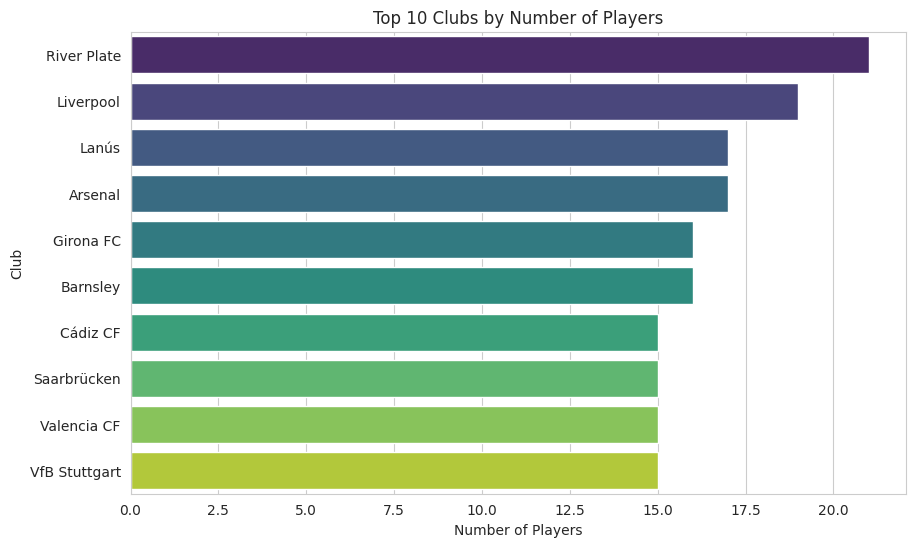

In [6]:
import matplotlib.pyplot as xyz_plt
import seaborn as xyz_sns

xyz_sns.set_style('whitegrid')

xyz_top_n = 10
xyz_club_counts = xyz_dataframe['club'].value_counts().nlargest(xyz_top_n).reset_index()
xyz_club_counts.columns = ['club', 'player_count']

xyz_fig_club, xyz_ax_club = xyz_plt.subplots(figsize=(10, 6))

xyz_sns.barplot(
    data=xyz_club_counts,
    x='player_count',
    y='club',
    ax=xyz_ax_club,
    palette='viridis'
)

xyz_ax_club.set_title(f'Top {xyz_top_n} Clubs by Number of Players')
xyz_ax_club.set_xlabel('Number of Players')
xyz_ax_club.set_ylabel('Club')

xyz_fig_club.savefig('TopClubs_BarChart.png')

### **Performance vs. Value (Scatter Plot)**

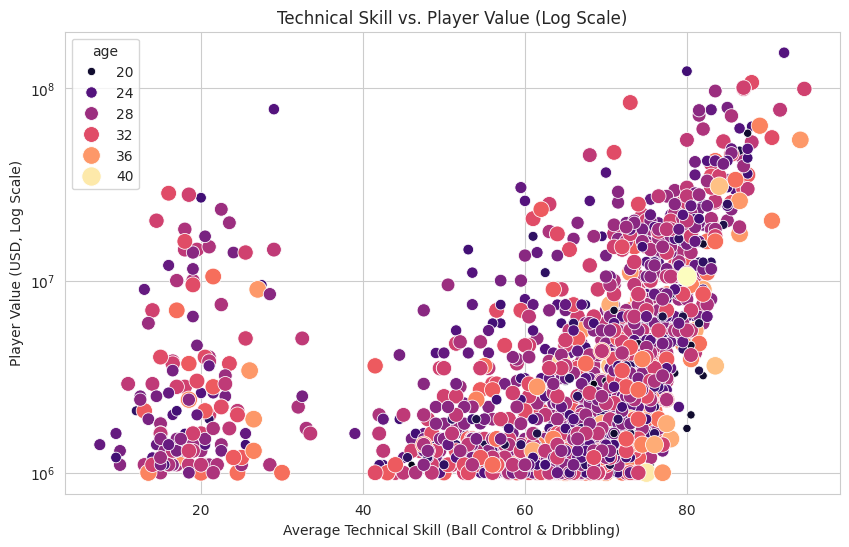

In [7]:
import numpy as xyz_numpy

# Calculate an average technical skill score
xyz_dataframe['Technical_Skill'] = xyz_dataframe[['ball_control', 'dribbling']].mean(axis=1)

# Filter out players with very low value for clearer visualization
xyz_plot_df = xyz_dataframe.dropna(subset=['Technical_Skill', 'value'])
xyz_plot_df = xyz_plot_df[xyz_plot_df['value'] > 100000]

xyz_fig_scatter, xyz_ax_scatter = xyz_plt.subplots(figsize=(10, 6))

xyz_sns.scatterplot(
    data=xyz_plot_df,
    x='Technical_Skill',
    y='value',
    ax=xyz_ax_scatter,
    hue='age',
    size='age',
    sizes=(20, 200),
    palette='magma'
)

# Set logarithmic scale for 'value'
xyz_ax_scatter.set_yscale('log')
xyz_ax_scatter.set_title('Technical Skill vs. Player Value (Log Scale)')
xyz_ax_scatter.set_xlabel('Average Technical Skill (Ball Control & Dribbling)')
xyz_ax_scatter.set_ylabel('Player Value (USD, Log Scale)')

xyz_fig_scatter.savefig('SkillVsValue_ScatterPlot.png')

### **Average Player Value by Country (Bar Chart)**

/tmp/ipython-input-2330079511.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  xyz_sns.barplot(
/tmp/ipython-input-2330079511.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  xyz_ax_country.set_xticklabels(xyz_ticks)


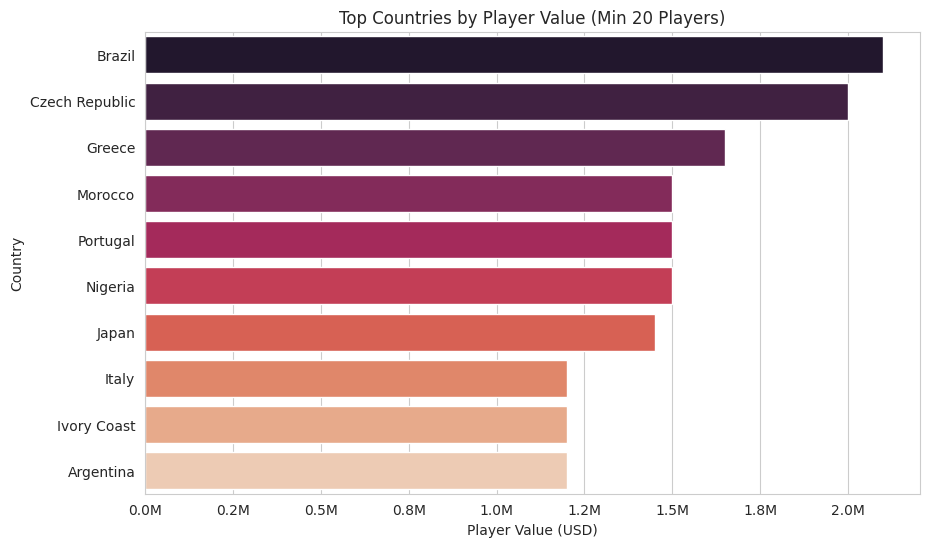

In [8]:

import matplotlib.pyplot as xyz_plt
import seaborn as xyz_sns

xyz_min_players = 20

# Calculate median value and count per country
xyz_country_stats = xyz_dataframe.groupby('country').agg(
    average_value=('value', 'median'),
    player_count=('player', 'count')
).reset_index()

# Filter for countries with enough players, sort by median value, and select top 10
xyz_country_stats = xyz_country_stats[xyz_country_stats['player_count'] >= xyz_min_players]
xyz_country_stats = xyz_country_stats.sort_values('average_value', ascending=False).head(10)

xyz_fig_country, xyz_ax_country = xyz_plt.subplots(figsize=(10, 6))

xyz_sns.barplot(
    data=xyz_country_stats,
    x='average_value',
    y='country',
    ax=xyz_ax_country,
    palette='rocket'
)

# Format x-axis labels to display value in millions
xyz_ticks = [f'{v/1000000:.1f}M' for v in xyz_ax_country.get_xticks()]
xyz_ax_country.set_xticklabels(xyz_ticks)

xyz_ax_country.set_title(f'Top Countries by Player Value (Min {xyz_min_players} Players)')
xyz_ax_country.set_xlabel('Player Value (USD)')
xyz_ax_country.set_ylabel('Country')

xyz_fig_country.savefig('MedianValueByCountry_BarChart.png')



---



---



### **1. Model Improvement and Optimization**
We will apply Feature Engineering (Scaling) and Hyperparameter Tuning using a Random Forest model.

In [9]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import time

# Step 1: Feature Selection and Engineering
# We use technical skills and physical attributes to predict 'value'
xyz_features = ['age', 'reactions', 'composure', 'ball_control', 'dribbling', 'Technical_Skill']
xyz_target = 'value'

# Cleaning data: Drop rows with missing values in our selected columns
xyz_ml_df = xyz_dataframe[xyz_features + [xyz_target]].dropna()

X = xyz_ml_df[xyz_features]
y = xyz_ml_df[xyz_target]

In [10]:
# Optimization: Feature Scaling
xyz_scaler = StandardScaler()
X_scaled = xyz_scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Data Prepared and Scaled.")

Data Prepared and Scaled.


### **Neural Network Training**

Training on your player data for 10 epochs...
Iteration 1, loss = 31490361361111.55468750
Iteration 2, loss = 31466586058359.03125000
Iteration 3, loss = 31343220814107.13671875
Iteration 4, loss = 30947065115021.33203125
Iteration 5, loss = 30109102932345.33593750
Iteration 6, loss = 28918076964902.20312500
Iteration 7, loss = 27838150610339.88281250
Iteration 8, loss = 27410875128115.21875000
Iteration 9, loss = 27374070864001.54296875
Iteration 10, loss = 27373858114235.69140625
Iteration 11, loss = 27376481375024.39062500
Iteration 12, loss = 27378885944998.05859375
Iteration 13, loss = 27382550847676.58203125
Iteration 14, loss = 27362864069782.21484375
Iteration 15, loss = 27364962118282.83984375
Iteration 16, loss = 27365494816915.80078125
Iteration 17, loss = 27360110393166.43750000
Iteration 18, loss = 27363755400191.66015625
Iteration 19, loss = 27366294234080.69921875
Iteration 20, loss = 27380191474497.02734375
Iteration 21, loss = 27361522786628.23437500
Iteration 22, loss

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (25) reached and the optimization hasn't converged yet.
  warnings.warn(


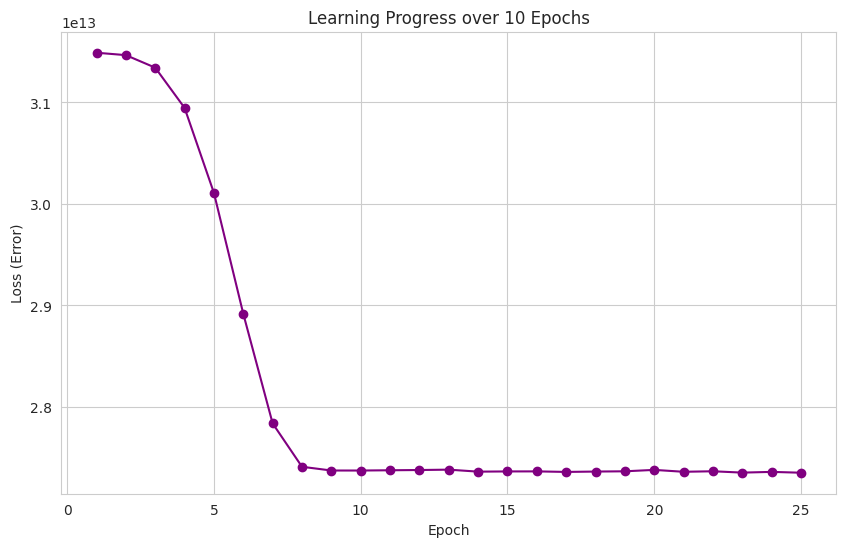

In [51]:
from sklearn.neural_network import MLPRegressor
epochs = 25
#building the Brain
xyz_model = MLPRegressor(
    hidden_layer_sizes=(100, 50),
    max_iter=epochs,
    random_state=42,
    verbose=True,
    learning_rate_init=0.01
)
print("Training on your player data for 10 epochs...")
xyz_model.fit(X_train, y_train)

# Plotting the loss
xyz_fig, xyz_ax = xyz_plt.subplots(figsize=(10, 6))
xyz_ax.plot(range(1, len(xyz_model.loss_curve_) + 1), xyz_model.loss_curve_, marker='o', color='purple')
xyz_ax.set_title('Learning Progress over 10 Epochs')
xyz_ax.set_xlabel('Epoch')
xyz_ax.set_ylabel('Loss (Error)')
xyz_ax.grid(True)
xyz_fig.savefig('Epoch_Training.png')

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


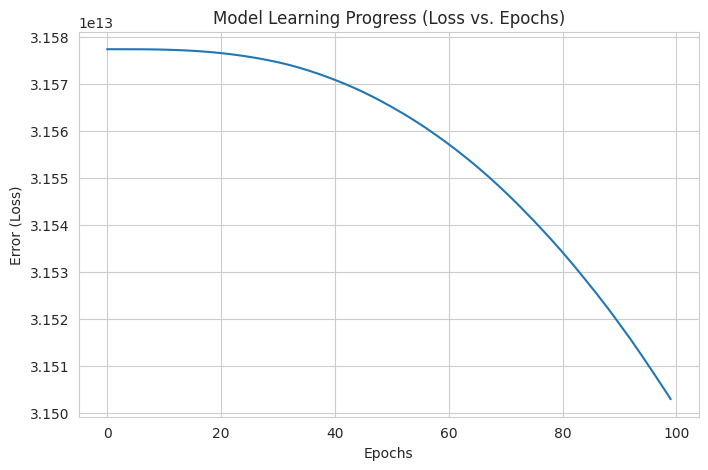

Final training error after 100 epochs: 31502963074143.34


In [27]:
# Initialize the model with 100 epochs
mlp = MLPRegressor(hidden_layer_sizes=(10, 10), max_iter=100, random_state=42)
mlp.fit(X_scaled, y)

# Visualizing the Learning Process over Epochs
xyz_fig_epochs, xyz_ax_epochs = xyz_plt.subplots(figsize=(8, 5))
xyz_ax_epochs.plot(mlp.loss_curve_)
xyz_ax_epochs.set_title('Model Learning Progress (Loss vs. Epochs)')
xyz_ax_epochs.set_xlabel('Epochs')
xyz_ax_epochs.set_ylabel('Error (Loss)')
xyz_plt.show()

print(f"Final training error after 100 epochs: {mlp.loss_curve_[-1]}")

### **2. Comparative Model Study**
We will compare a baseline Linear Regression model with an optimized Random Forest model.

In [11]:
# Model 1: Linear Regression (Baseline)
xyz_start_lr = time.time()
xyz_model_lr = LinearRegression()
xyz_model_lr.fit(X_train, y_train)
xyz_lr_time = time.time() - xyz_start_lr

# Model 2: Random Forest (Optimized with Hyperparameter Tuning)
xyz_rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None]
}

xyz_start_rf = time.time()
xyz_grid_search = GridSearchCV(RandomForestRegressor(random_state=42), xyz_rf_params, cv=3)
xyz_grid_search.fit(X_train, y_train)
xyz_model_rf = xyz_grid_search.best_estimator_
xyz_rf_time = time.time() - xyz_start_rf

print(f"Best RF Parameters: {xyz_grid_search.best_params_ }")

Best RF Parameters: {'max_depth': 10, 'n_estimators': 100}


### **3. Performance Evaluation and Analysis**

In [12]:
# Predictions
y_pred_lr = xyz_model_lr.predict(X_test)
y_pred_rf = xyz_model_rf.predict(X_test)

# Metrics calculation
def get_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": xyz_numpy.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

xyz_lr_metrics = get_metrics(y_test, y_pred_lr)
xyz_rf_metrics = get_metrics(y_test, y_pred_rf)

In [13]:
# Display Results
import pandas as pd
xyz_comparison_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2 Score", "Training Time (s)"],
    "Linear Regression": [xyz_lr_metrics['MAE'], xyz_lr_metrics['RMSE'], xyz_lr_metrics['R2'], xyz_lr_time],
    "Random Forest": [xyz_rf_metrics['MAE'], xyz_rf_metrics['RMSE'], xyz_rf_metrics['R2'], xyz_rf_time]
})
print(xyz_comparison_df)

              Metric  Linear Regression  Random Forest
0                MAE       3.075975e+06   8.674251e+05
1               RMSE       6.719211e+06   2.649137e+06
2           R2 Score       2.419046e-01   8.821591e-01
3  Training Time (s)       5.576396e-02   2.642821e+01


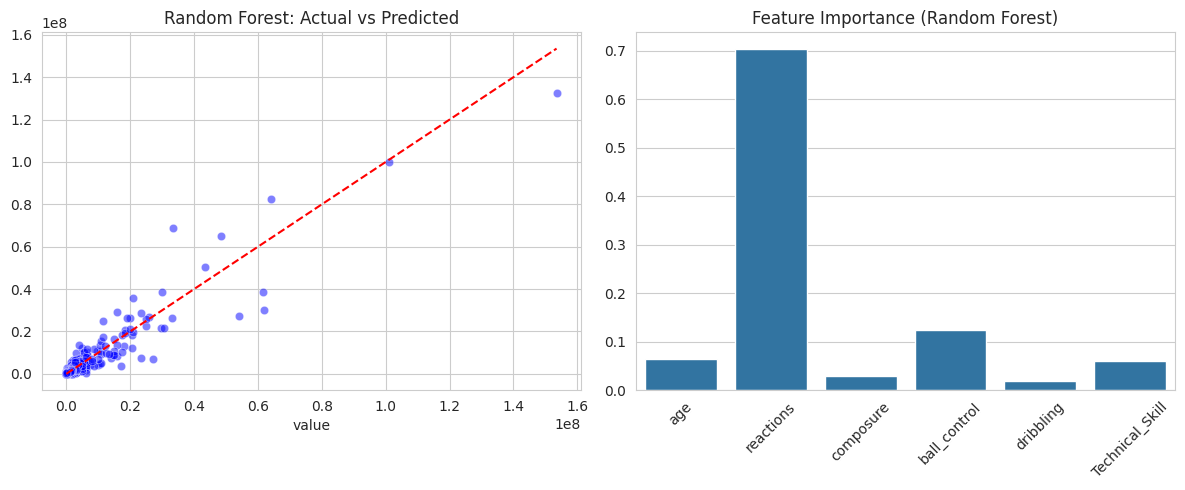

In [14]:
# Visualization: Actual vs Predicted
xyz_plt.figure(figsize=(12, 5))
xyz_plt.subplot(1, 2, 1)
xyz_sns.scatterplot(x=y_test, y=y_pred_rf, color='blue', alpha=0.5)
xyz_plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
xyz_plt.title("Random Forest: Actual vs Predicted")

xyz_plt.subplot(1, 2, 2)
xyz_sns.barplot(x=xyz_features, y=xyz_model_rf.feature_importances_)
xyz_plt.title("Feature Importance (Random Forest)")
xyz_plt.xticks(rotation=45)
xyz_plt.tight_layout()
xyz_plt.show()